In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

2026-04-01 20:47:42.342919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775076462.567908      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775076462.628812      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775076463.158961      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775076463.159002      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775076463.159005      55 computation_placer.cc:177] computation placer alr

In [2]:
augmented_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Augmented_Dataset"

original_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset"

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
class_names = sorted([
    d for d in os.listdir(augmented_dir)
    if os.path.isdir(os.path.join(augmented_dir, d))
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 3


In [5]:
def get_image_paths_and_labels(data_dir, class_names):
    file_paths = []
    labels = []

    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_ext):
                file_paths.append(os.path.join(class_path, file_name))
                labels.append(idx)

    return file_paths, labels

train_paths, train_labels = get_image_paths_and_labels(augmented_dir, class_names)
original_paths, original_labels = get_image_paths_and_labels(original_dir, class_names)

print("Training images from Augmented_Dataset:", len(train_paths))
print("Images from Original_Dataset:", len(original_paths))

Training images from Augmented_Dataset: 10185
Images from Original_Dataset: 2037


In [6]:
val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_paths,
    original_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_labels
)

print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Validation images: 1018
Test images: 1019


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

I0000 00:00:1775076489.714114      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775076489.717028      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [9]:
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
test_ds = create_dataset(test_paths, test_labels, training=False)

print("Datasets created successfully.")

Datasets created successfully.


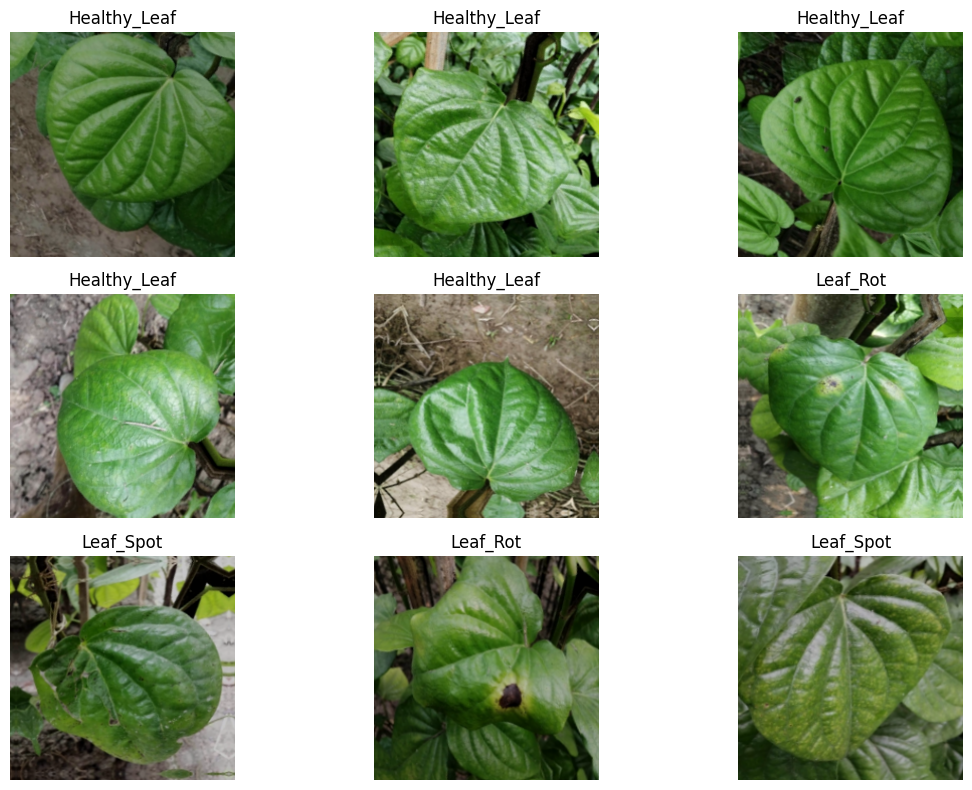

In [10]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
input_layer = layers.Input(shape=(224, 224, 3), name="input_image")

# Branch 1: EfficientNetB0
x1 = layers.Lambda(efficientnet_preprocess, name="efficientnet_preprocess")(input_layer)
efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
efficientnet_base.trainable = False
x1 = efficientnet_base(x1, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.Dense(128, activation="relu")(x1)

# Branch 2: DenseNet121
x2 = layers.Lambda(densenet_preprocess, name="densenet_preprocess")(input_layer)
densenet_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
densenet_base.trainable = False
x2 = densenet_base(x2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.Dense(128, activation="relu")(x2)

# Late Fusion
fusion = layers.Concatenate(name="late_fusion_concat")([x1, x2])
fusion = layers.Dense(256, activation="relu")(fusion)
fusion = layers.Dropout(0.4)(fusion)
fusion = layers.Dense(128, activation="relu")(fusion)

output_layer = layers.Dense(num_classes, activation="softmax", name="output")(fusion)

model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LateFusion_EfficientNetB0_DenseNet121"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "LateFusion_EfficientNetB0_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_prepr… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preprocess │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ efficientnet_pre… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    131,200 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ late_fusion_conc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        387 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,481,318 (43.80 MB)

 Trainable params: 394,243 (1.50 MB)

 Non-trainable params: 11,087,075 (42.29 MB)

In [13]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "late_fusion_pipeline3_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775076518.900114     126 service.cc:152] XLA service 0x7aac0c27c920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775076518.900151     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775076518.900156     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775076524.603488     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-01 20:48:52.644104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:48:52.787505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:48:53.126504: E external/local_xl

318/319 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.6171 - loss: 0.8470

2026-04-01 20:50:51.408804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:50:51.545395: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:50:51.853138: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:50:51.993802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:50:52.758711: E external/local_xla/xla/stream_

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6175 - loss: 0.8464

2026-04-01 20:51:36.526393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:51:36.669235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:51:37.000723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:51:37.141923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 20:51:37.925988: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.84774, saving model to late_fusion_pipeline3_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 215s 507ms/step - accuracy: 0.6178 - loss: 0.8458 - val_accuracy: 0.8477 - val_loss: 0.3946 - learning_rate: 1.0000e-04
Epoch 2/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.8574 - loss: 0.3931
Epoch 2: val_accuracy improved from 0.84774 to 0.86149, saving model to late_fusion_pipeline3_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 88s 276ms/step - accuracy: 0.8574 - loss: 0.3930 - val_accuracy: 0.8615 - val_loss: 0.3593 - learning_rate: 1.0000e-04
Epoch 3/20
318/319 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8796 - loss: 0.3279
Epoch 3: val_accuracy improved from 0.86149 to 0.87819, saving model to late_fusion_pipeline3_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 90s 280ms/step - accuracy: 0.8796 - loss: 0.3279 - val_accuracy: 0.8782 - val_loss: 0.3120 - learning_rate: 1.0000e-04
Epoch 4/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 

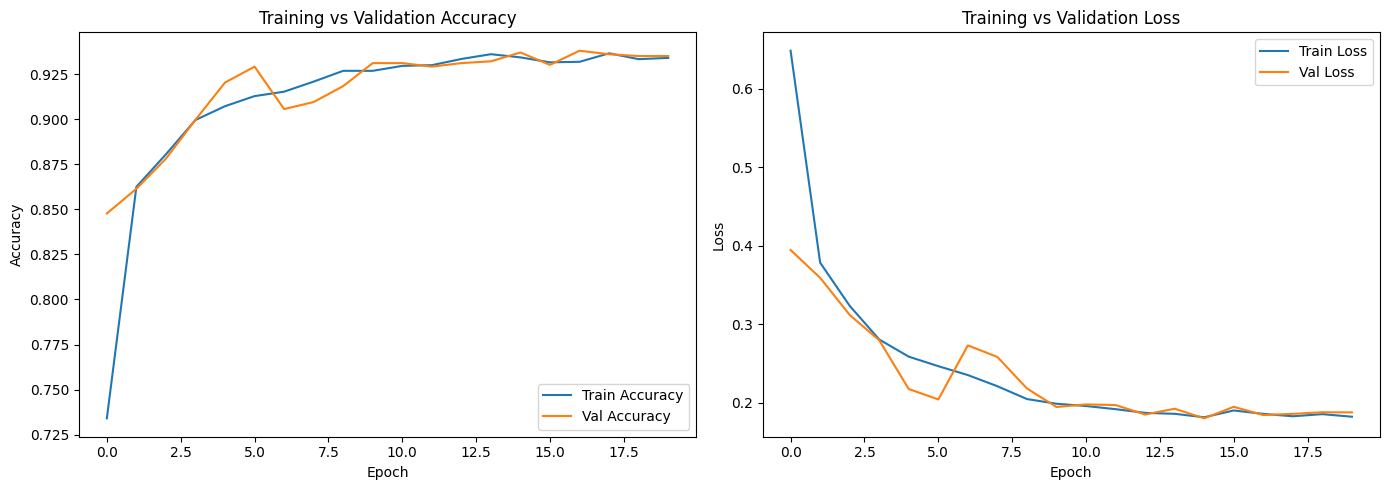

In [15]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9128 - loss: 0.2452

2026-04-01 21:20:09.530598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 21:20:09.673674: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 21:20:10.016819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 21:20:10.158173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 21:20:10.932994: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 835ms/step - accuracy: 0.9134 - loss: 0.2431
Test Loss: 0.2112870216369629
Test Accuracy: 0.9234543442726135


In [17]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 662ms/step
              precision    recall  f1-score   support

Healthy_Leaf       0.96      0.94      0.95       540
    Leaf_Rot       0.99      0.70      0.82       135
   Leaf_Spot       0.86      0.98      0.91       344

    accuracy                           0.92      1019
   macro avg       0.94      0.88      0.90      1019
weighted avg       0.93      0.92      0.92      1019



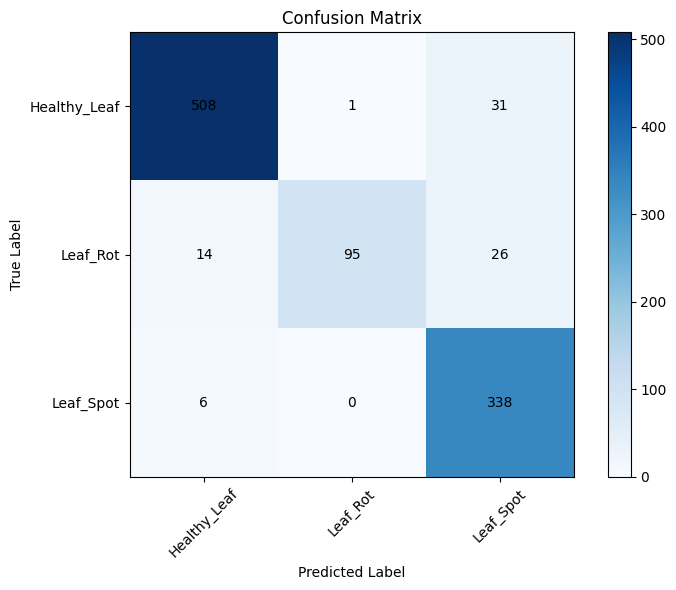

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [19]:
model.save("late_fusion_pipeline3_final.keras")
print("Model saved successfully.")

Model saved successfully.
